In [1]:
from src import *
import matplotlib.pyplot as plt

logger = logging.getLogger("global_logger")
logging.basicConfig(filename='gap_analysis.log',format='%(levelname)s: %(message)s', encoding='utf-8', filemode='w', level=logging.DEBUG)
logger.info("NEW START")

replay_settings = SimulationParameters("default")
action_names = ["kick", "sidestep", "turn", "walk"]
simulator = Simulator()

gap_handler = simulator.simulation_gap(settings=replay_settings)

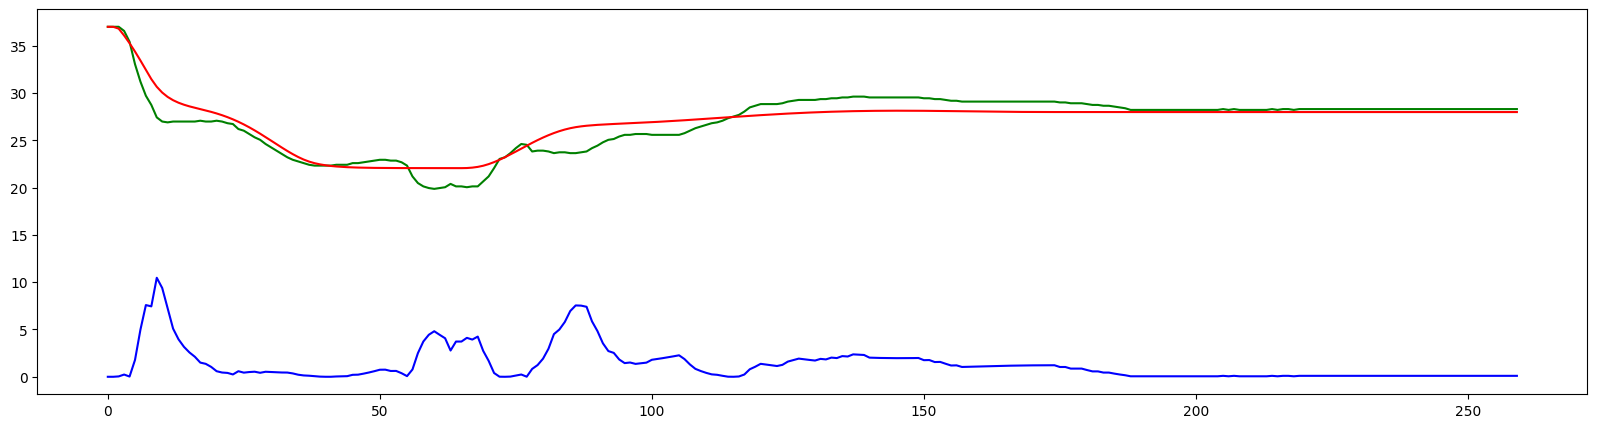

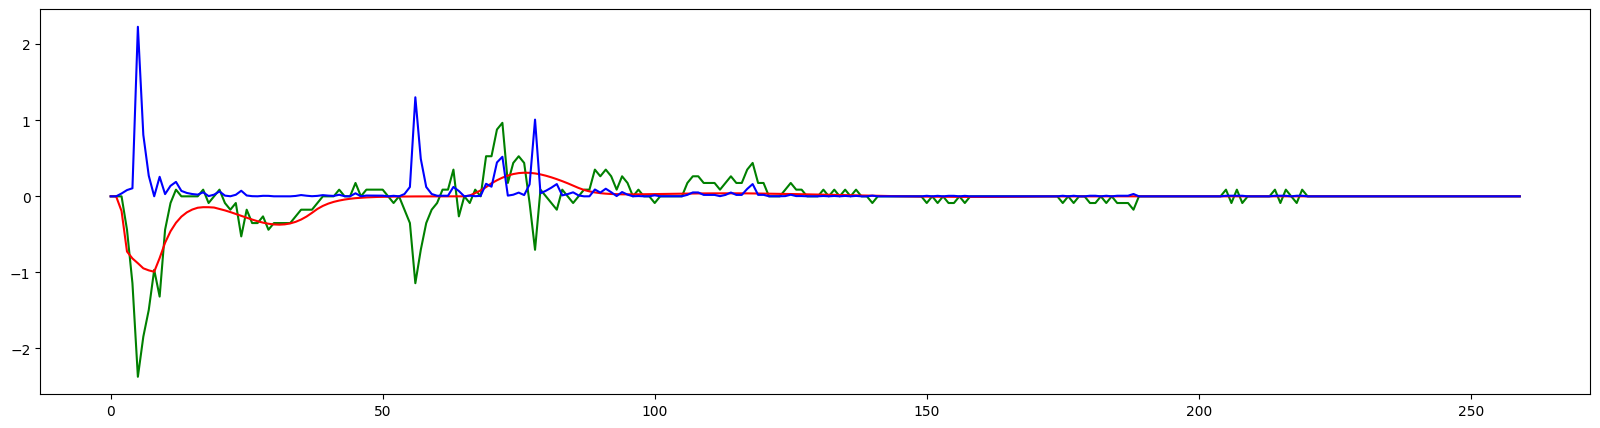

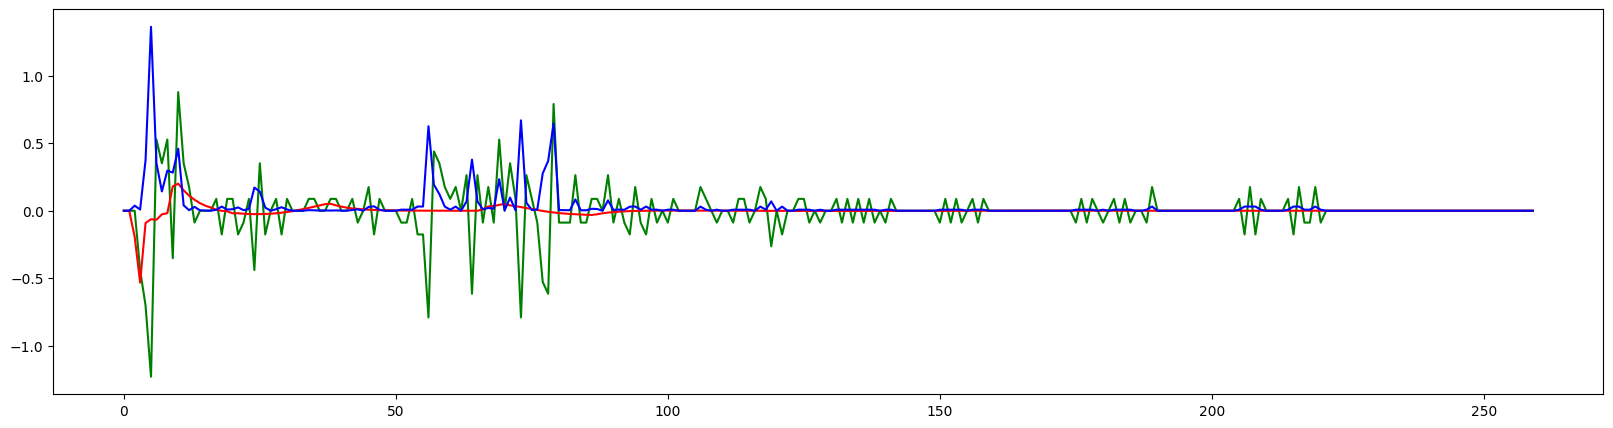

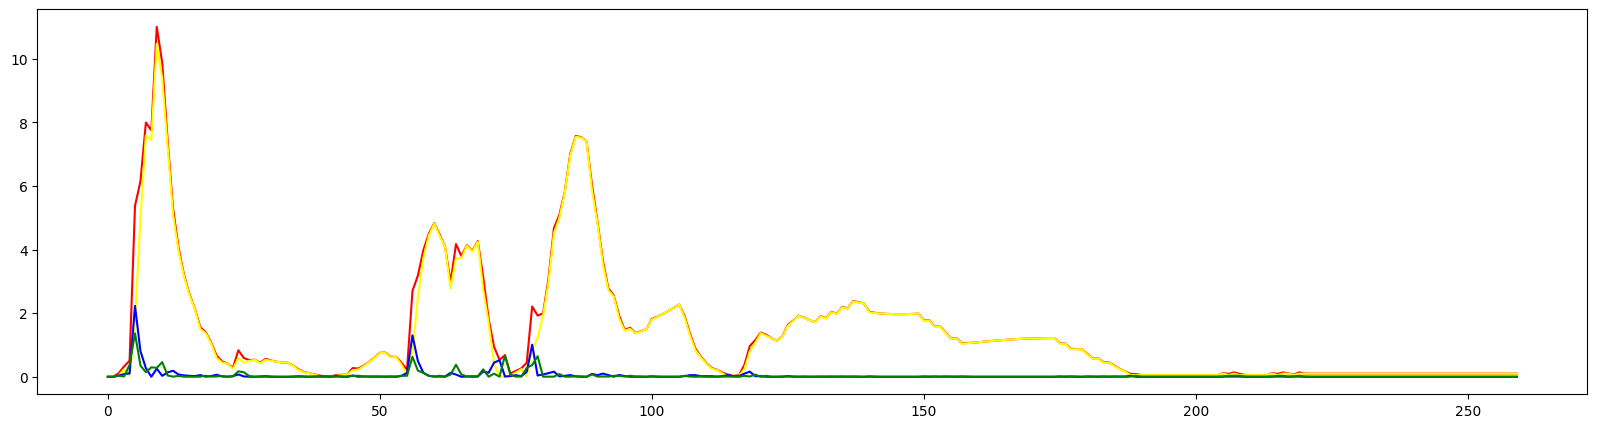

In [7]:
test_action = "kick"
test_index = 1
test_joint = "rKneePitch"
start_frame = 0
end_frame = -1
line_type = '-'

value_test = gap_handler.get_at(test_action, test_index)
value_test.load()
pos_extraction = value_test.get_pos_extraction(hinge_names=[test_joint], start_frame=start_frame, end_frame=end_frame)
vel_extraction = value_test.get_vel_extraction(hinge_names=[test_joint], start_frame=start_frame, end_frame=end_frame)
acc_extraction = value_test.get_acc_extraction(hinge_names=[test_joint], start_frame=start_frame, end_frame=end_frame)
pos_replay = value_test.get_pos_replay(hinge_names=[test_joint], start_frame=start_frame, end_frame=end_frame)
vel_replay = value_test.get_vel_replay(hinge_names=[test_joint], start_frame=start_frame, end_frame=end_frame)
acc_replay = value_test.get_acc_replay(hinge_names=[test_joint], start_frame=start_frame, end_frame=end_frame)
pos_gap = value_test.get_pos_gap(hinge_names=[test_joint], start_frame=start_frame, end_frame=end_frame)
vel_gap = value_test.get_vel_gap(hinge_names=[test_joint], start_frame=start_frame, end_frame=end_frame)
acc_gap = value_test.get_acc_gap(hinge_names=[test_joint], start_frame=start_frame, end_frame=end_frame)
total_gap = value_test.get_total_gap(hinge_names=[test_joint], start_frame=start_frame, end_frame=end_frame)

value_test.unload()
plt.figure(figsize=(20, 5))
plt.plot(range(len(pos_extraction[test_joint])), pos_extraction[test_joint],line_type, color="green")
plt.plot(range(len(pos_replay[test_joint])), pos_replay[test_joint],line_type, color="red")
plt.plot(range(len(pos_gap[test_joint])), pos_gap[test_joint],line_type, color="blue")
plt.show()
plt.figure(figsize=(20, 5))
plt.plot(range(len(vel_extraction[test_joint])), vel_extraction[test_joint],line_type, color="green")
plt.plot(range(len(vel_replay[test_joint])), vel_replay[test_joint],line_type, color="red")
plt.plot(range(len(vel_gap[test_joint])), vel_gap[test_joint],line_type, color="blue")
plt.show()
plt.figure(figsize=(20, 5))
plt.plot(range(len(acc_extraction[test_joint])), acc_extraction[test_joint],line_type, color="green")
plt.plot(range(len(acc_replay[test_joint])), acc_replay[test_joint], line_type, color="red")
plt.plot(range(len(acc_gap[test_joint])), acc_gap[test_joint], line_type, color="blue")
plt.show()
plt.figure(figsize=(20, 5))
plt.plot(range(len(total_gap[test_joint])), total_gap[test_joint], line_type, color="red")
plt.plot(range(len(pos_gap[test_joint])), pos_gap[test_joint], line_type, color="yellow")
plt.plot(range(len(vel_gap[test_joint])), vel_gap[test_joint], line_type, color="blue")
plt.plot(range(len(acc_gap[test_joint])), acc_gap[test_joint], line_type, color="green")
plt.show()

In [3]:
# averages and stuff:
for go in gap_handler.get():
    go.load()
    print(go.get_total_gap_avg())
    go.unload()

57.17408040999512
10.816284072405828
10.782174068309294
10.654103793056203
10.799540187413236
10.768841130997808
10.717356591759462
12.328765943457311
12.336270323458226
12.28032757794153
12.135010041734313
12.241575372560941
12.59747105315361
12.489239790926918
12.790739108037949
12.686217865542943
12.542188056122598
12.095024958381044
12.324728334527327
12.380012594037845
12.32399523697424
12.334033303947793


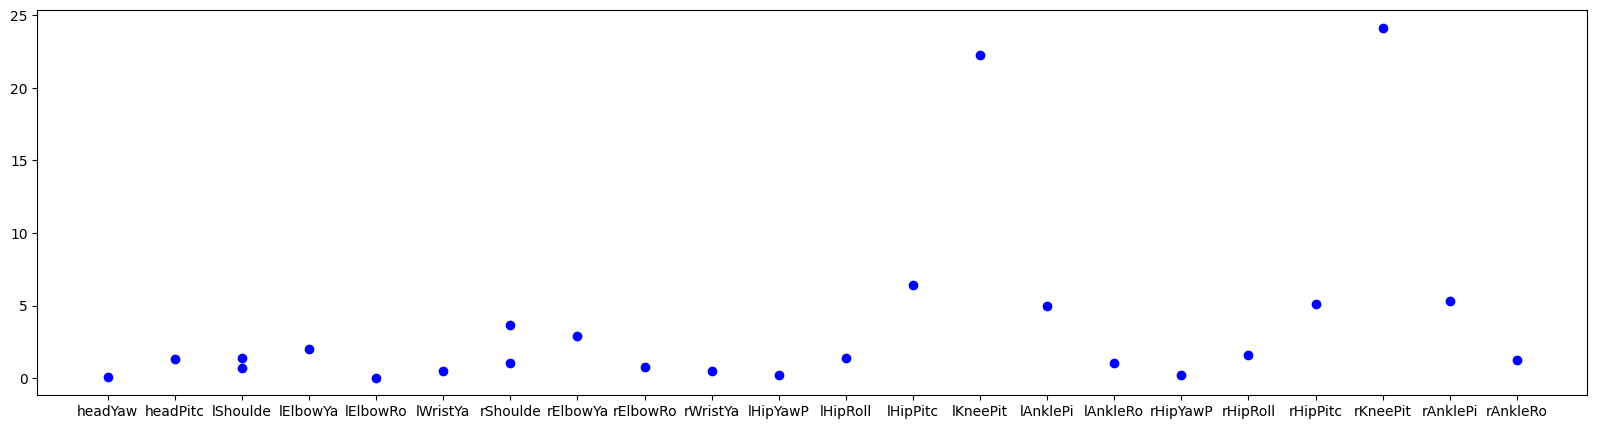

In [4]:
go1 = gap_handler.get_at(action_name="walk", index=1)
go1.load()
gap0 = go1.get_total_gap_frame_avg()
gap1 = go1.get_pos_gap_frame_avg()
gap2 = go1.get_vel_gap_frame_avg()
gap3 = go1.get_acc_gap_frame_avg()
plt.figure(figsize=(20, 5))
plt.plot([s[:8] for s in gap0.keys()], gap0.values(), 'o', color="blue")
#plt.plot([s[:8] for s in gap1.keys()], gap1.values(), 'o', color="red")
#plt.plot([s[:8] for s in gap2.keys()], gap2.values(), 'o', color="green")
#plt.plot([s[:8] for s in gap3.keys()], gap3.values(), 'o', color="yellow")

plt.show()

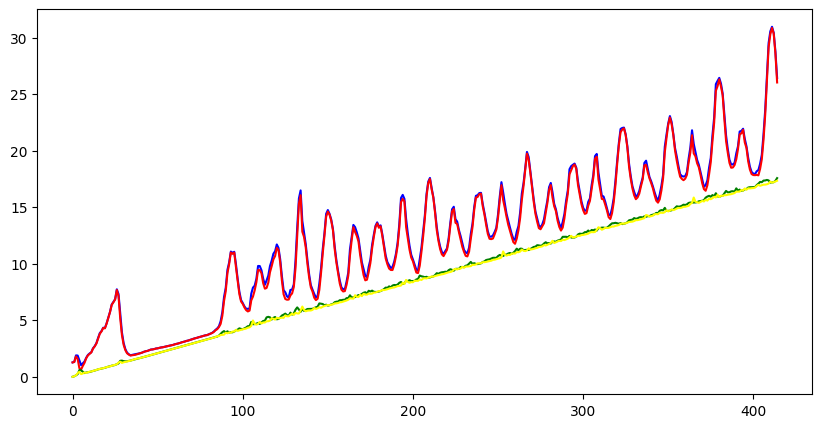

In [5]:
gap0 = go1.get_total_gap_joint_avg()
gap1 = go1.get_pos_gap_joint_avg()
gap2 = go1.get_vel_gap_joint_avg()
gap3 = go1.get_acc_gap_joint_avg()
plt.figure(figsize=(10, 5))
plt.plot(list(range(len(gap0))), gap0, color="blue")
plt.plot(list(range(len(gap1))), gap1, color="red")
plt.plot(list(range(len(gap2))), gap2, color="green")
plt.plot(list(range(len(gap3))), gap3, color="yellow")

plt.show()

In [6]:
gap3 = gap_handler.get_frame_avg("kick")
plt.figure(figsize=(10, 5))
plt.plot(list(range(len(gap3))), gap3, color="blue")

KeyError: 'headYaw'